In [1]:
import kagglehub
import json
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\glebo\Documents\University\Machine Learning\project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("../kaggle_token.json", "r") as f:
    kaggle_acc = json.load(f)

os.environ["KAGGLE_USERNAME"] = kaggle_acc["username"]
os.environ["KAGGLE_KEY"] = kaggle_acc["key"]

path = kagglehub.competition_download('uds-machine-learning-2026-regression')

print("Path to competition files:", path)

Path to competition files: C:\Users\glebo\.cache\kagglehub\competitions\uds-machine-learning-2026-regression


In [3]:
train = pd.read_csv(path+"/train.csv")

TARGET = "Rented Bike Count"

train = train.dropna()

X = train.drop(columns=[TARGET, "Date"])
y = train[TARGET]

train.head(2)


,Kaggle_ID,Date,Hour,Temperature,Humidity,Wind speed,Visibility,Dew point temperature,Solar Radiation,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Record_id,Rented Bike Count
0,0,15/05/2018,11,24.8,36,1.8,973,8.7,2.7,0.0,0.0,Sprng,No Holiday,Yes,5137441,943
1,1,7/9/2018,23,12.9,0,2.4,1688,50.9,0.0,2.4,1.4,Sproing,No Holiday,No,1465289,156


In [4]:
# Useful columns only

X = X.drop(columns=["Kaggle_ID", "Record_id"])
X.columns

Index(['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility',
       'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall',
       'Seasons', 'Holiday', 'Functioning Day'],
      dtype='str')

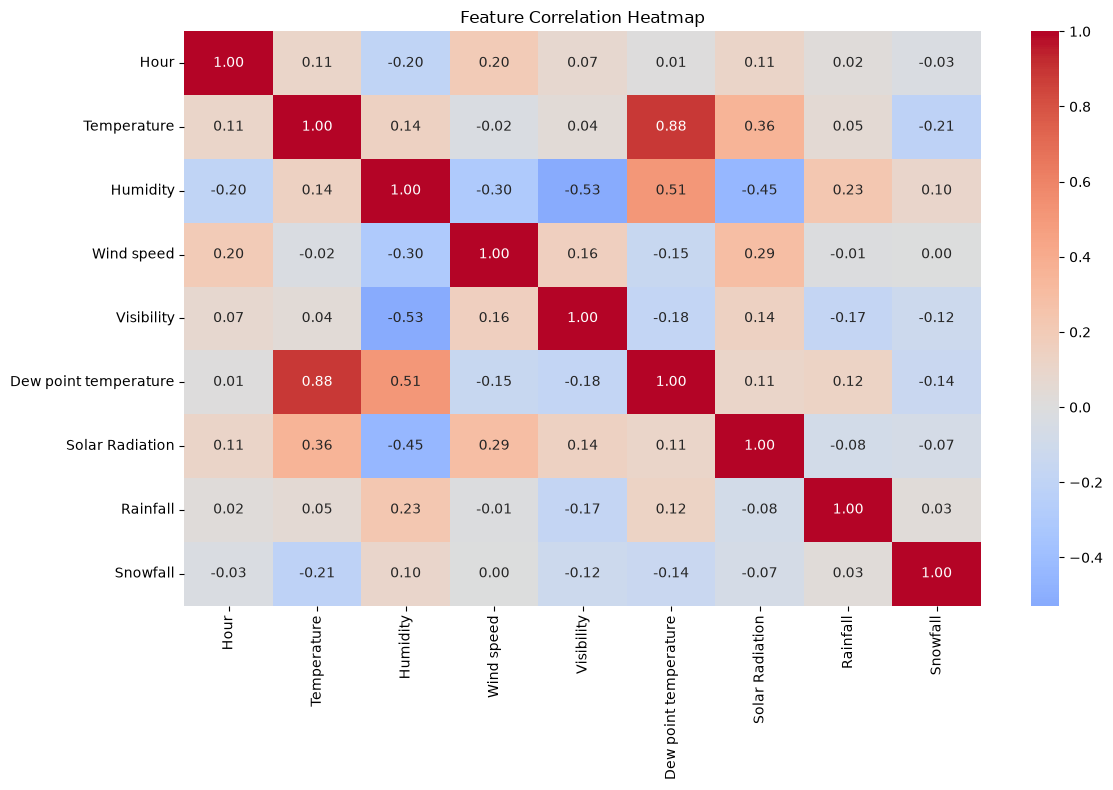

In [5]:
corr = X.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [6]:
### Data exploration

# Check nans
print(X.isna().sum())

# Check values
for col in X.columns:
    print(f"\n=== {col} ===")
    print(f"Type: {X[col].dtype}")

    if X[col].dtype == "object" or X[col].dtype.name == "category" or X[col].dtype.name == "str":
        print("Type: categorical")
        print("Values:")
        print(X[col].dropna().unique())

    else:
        print("Type: quantitative")
        print(f"Range: {X[col].min()} -> {X[col].max()}")

Hour                     0
Temperature              0
Humidity                 0
Wind speed               0
Visibility               0
Dew point temperature    0
Solar Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning Day          0
dtype: int64

=== Hour ===
Type: int64
Type: quantitative
Range: -10 -> 23

=== Temperature ===
Type: float64
Type: quantitative
Range: -37.2 -> 55.8

=== Humidity ===
Type: int64
Type: quantitative
Range: 0 -> 98

=== Wind speed ===
Type: float64
Type: quantitative
Range: -2.0 -> 15.7

=== Visibility ===
Type: int64
Type: quantitative
Range: 0 -> 2500

=== Dew point temperature ===
Type: float64
Type: quantitative
Range: -30.6 -> 61.2

=== Solar Radiation ===
Type: float64
Type: quantitative
Range: 0.0 -> 3.52

=== Rainfall ===
Type: float64
Type: quantitative
Range: 0.0 -> 29.5

=== Snowfall ===
Type: float64
Type: quantitative
Range: 0.0 -> 7.1

=== Seasons ===
Typ

In [7]:
# Fix categorical data

import re

def fix_season(df, season_column: str = "Seasons"):
    df[season_column] = (
        df[season_column]
        .str.replace(r".*A.*t.*m.*", "Autumn", regex=True)
        .str.replace(r".*Sp.*", "Spring", regex=True)
        .str.replace(r".*S.*m.*r.*", "Summer", regex=True)
        .str.replace(r".*W.*t.*r.*", "Winter", regex=True))
    return df

X = fix_season(X)
X["Seasons"].unique()

<StringArray>
['Spring', 'Summer', 'Winter', 'Autumn']
Length: 4, dtype: str

array([[<Axes: title={'center': 'Hour'}>,
        <Axes: title={'center': 'Temperature'}>,
        <Axes: title={'center': 'Humidity'}>],
       [<Axes: title={'center': 'Wind speed'}>,
        <Axes: title={'center': 'Visibility'}>,
        <Axes: title={'center': 'Dew point temperature'}>],
       [<Axes: title={'center': 'Solar Radiation'}>,
        <Axes: title={'center': 'Rainfall'}>,
        <Axes: title={'center': 'Snowfall'}>]], dtype=object)

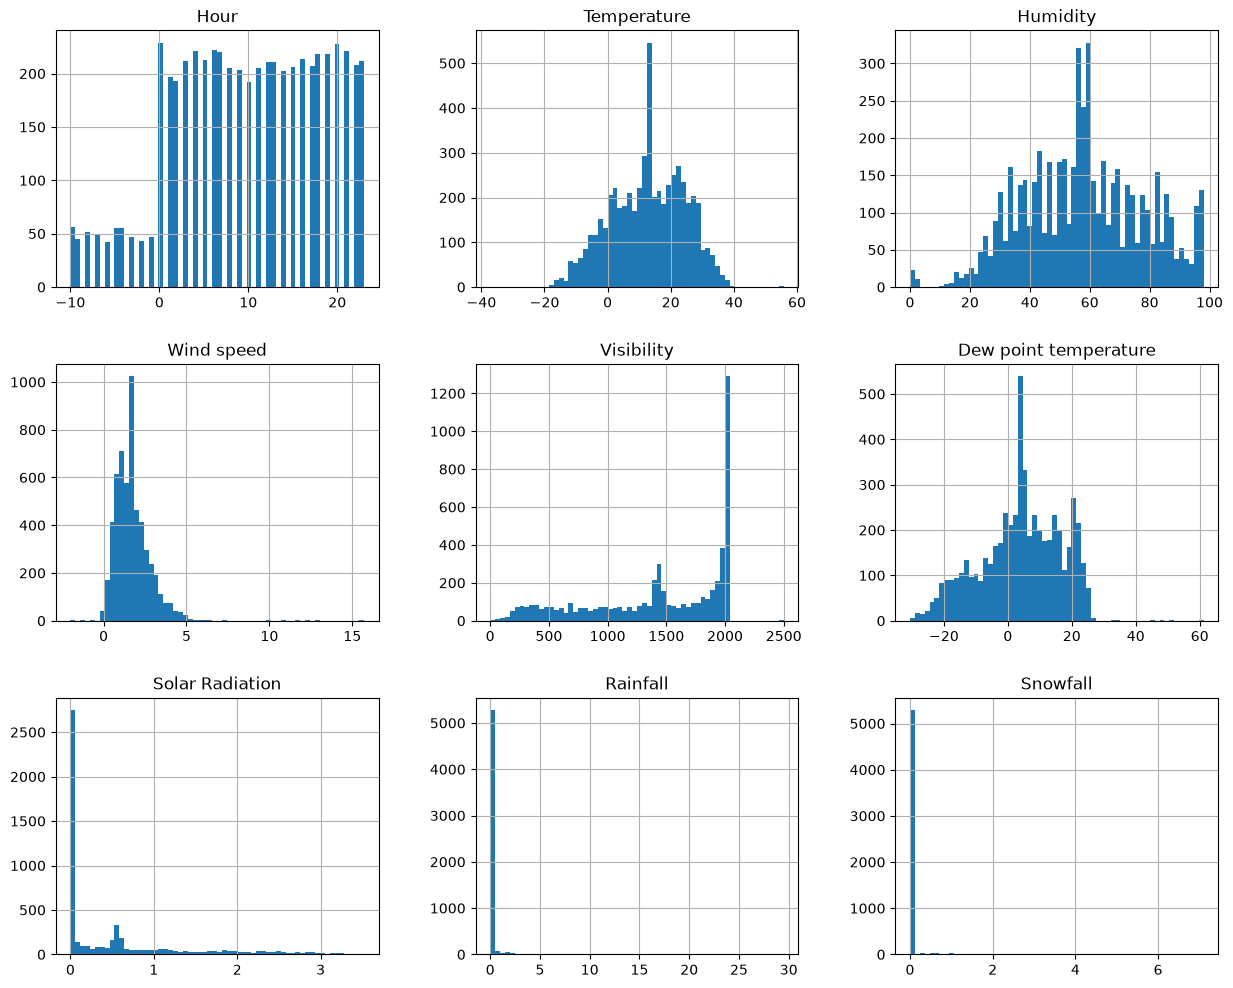

In [8]:
# get density of each value of the feature

X.hist(
    bins=60,
    figsize=(15, 12)
)

In [ ]:
print("Count of invalid Hour entries: ", X[X.Hour < 0].count())
print("Count of entries befpre deletion: ", X.size)
X = X[X.Hour >= 0]
print("Count of entries after deletion: ", X.size)

Count of invalid Hour entries:  Hour                     492
Temperature              492
Humidity                 492
Wind speed               492
Visibility               492
Dew point temperature    492
Solar Radiation          492
Rainfall                 492
Snowfall                 492
Seasons                  492
Holiday                  492
Functioning Day          492
dtype: int64
Count of entries befpre deletion:  66720
Count of entries after deletion:  66720


In [10]:
categorical_cols = X.select_dtypes(include=["object", "str"]).columns
numerical_cols = X.select_dtypes(include=["number"]).columns
print("Categorical: ", categorical_cols)
print("Numerical: ", numerical_cols)

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_encoded = encoder.fit_transform(X[categorical_cols])

X_encoded = pd.DataFrame(
    X_encoded,
    columns=encoder.get_feature_names_out(categorical_cols),
    index=X.index
)

X = pd.concat(
    [X[numerical_cols], X_encoded],
    axis=1
)

Categorical:  Index(['Seasons', 'Holiday', 'Functioning Day'], dtype='str')
Numerical:  Index(['Hour', 'Temperature', 'Humidity', 'Wind speed', 'Visibility',
       'Dew point temperature', 'Solar Radiation', 'Rainfall', 'Snowfall'],
      dtype='str')


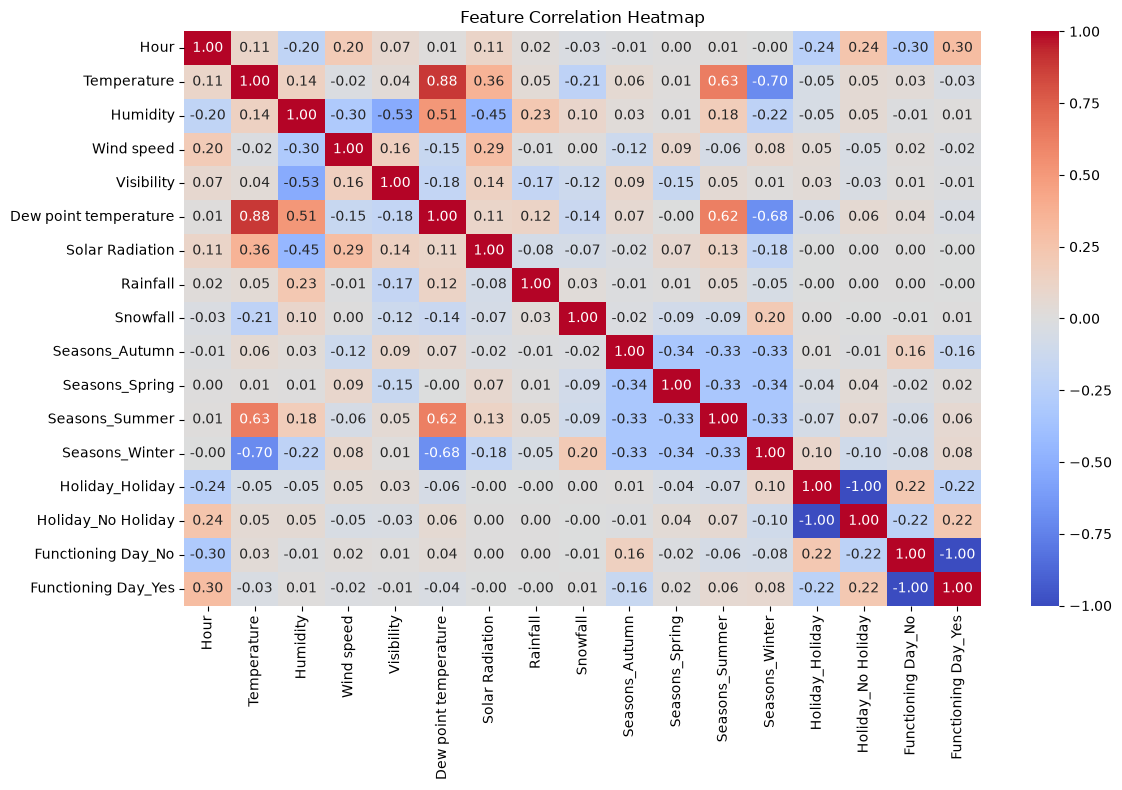

In [11]:
corr = X.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

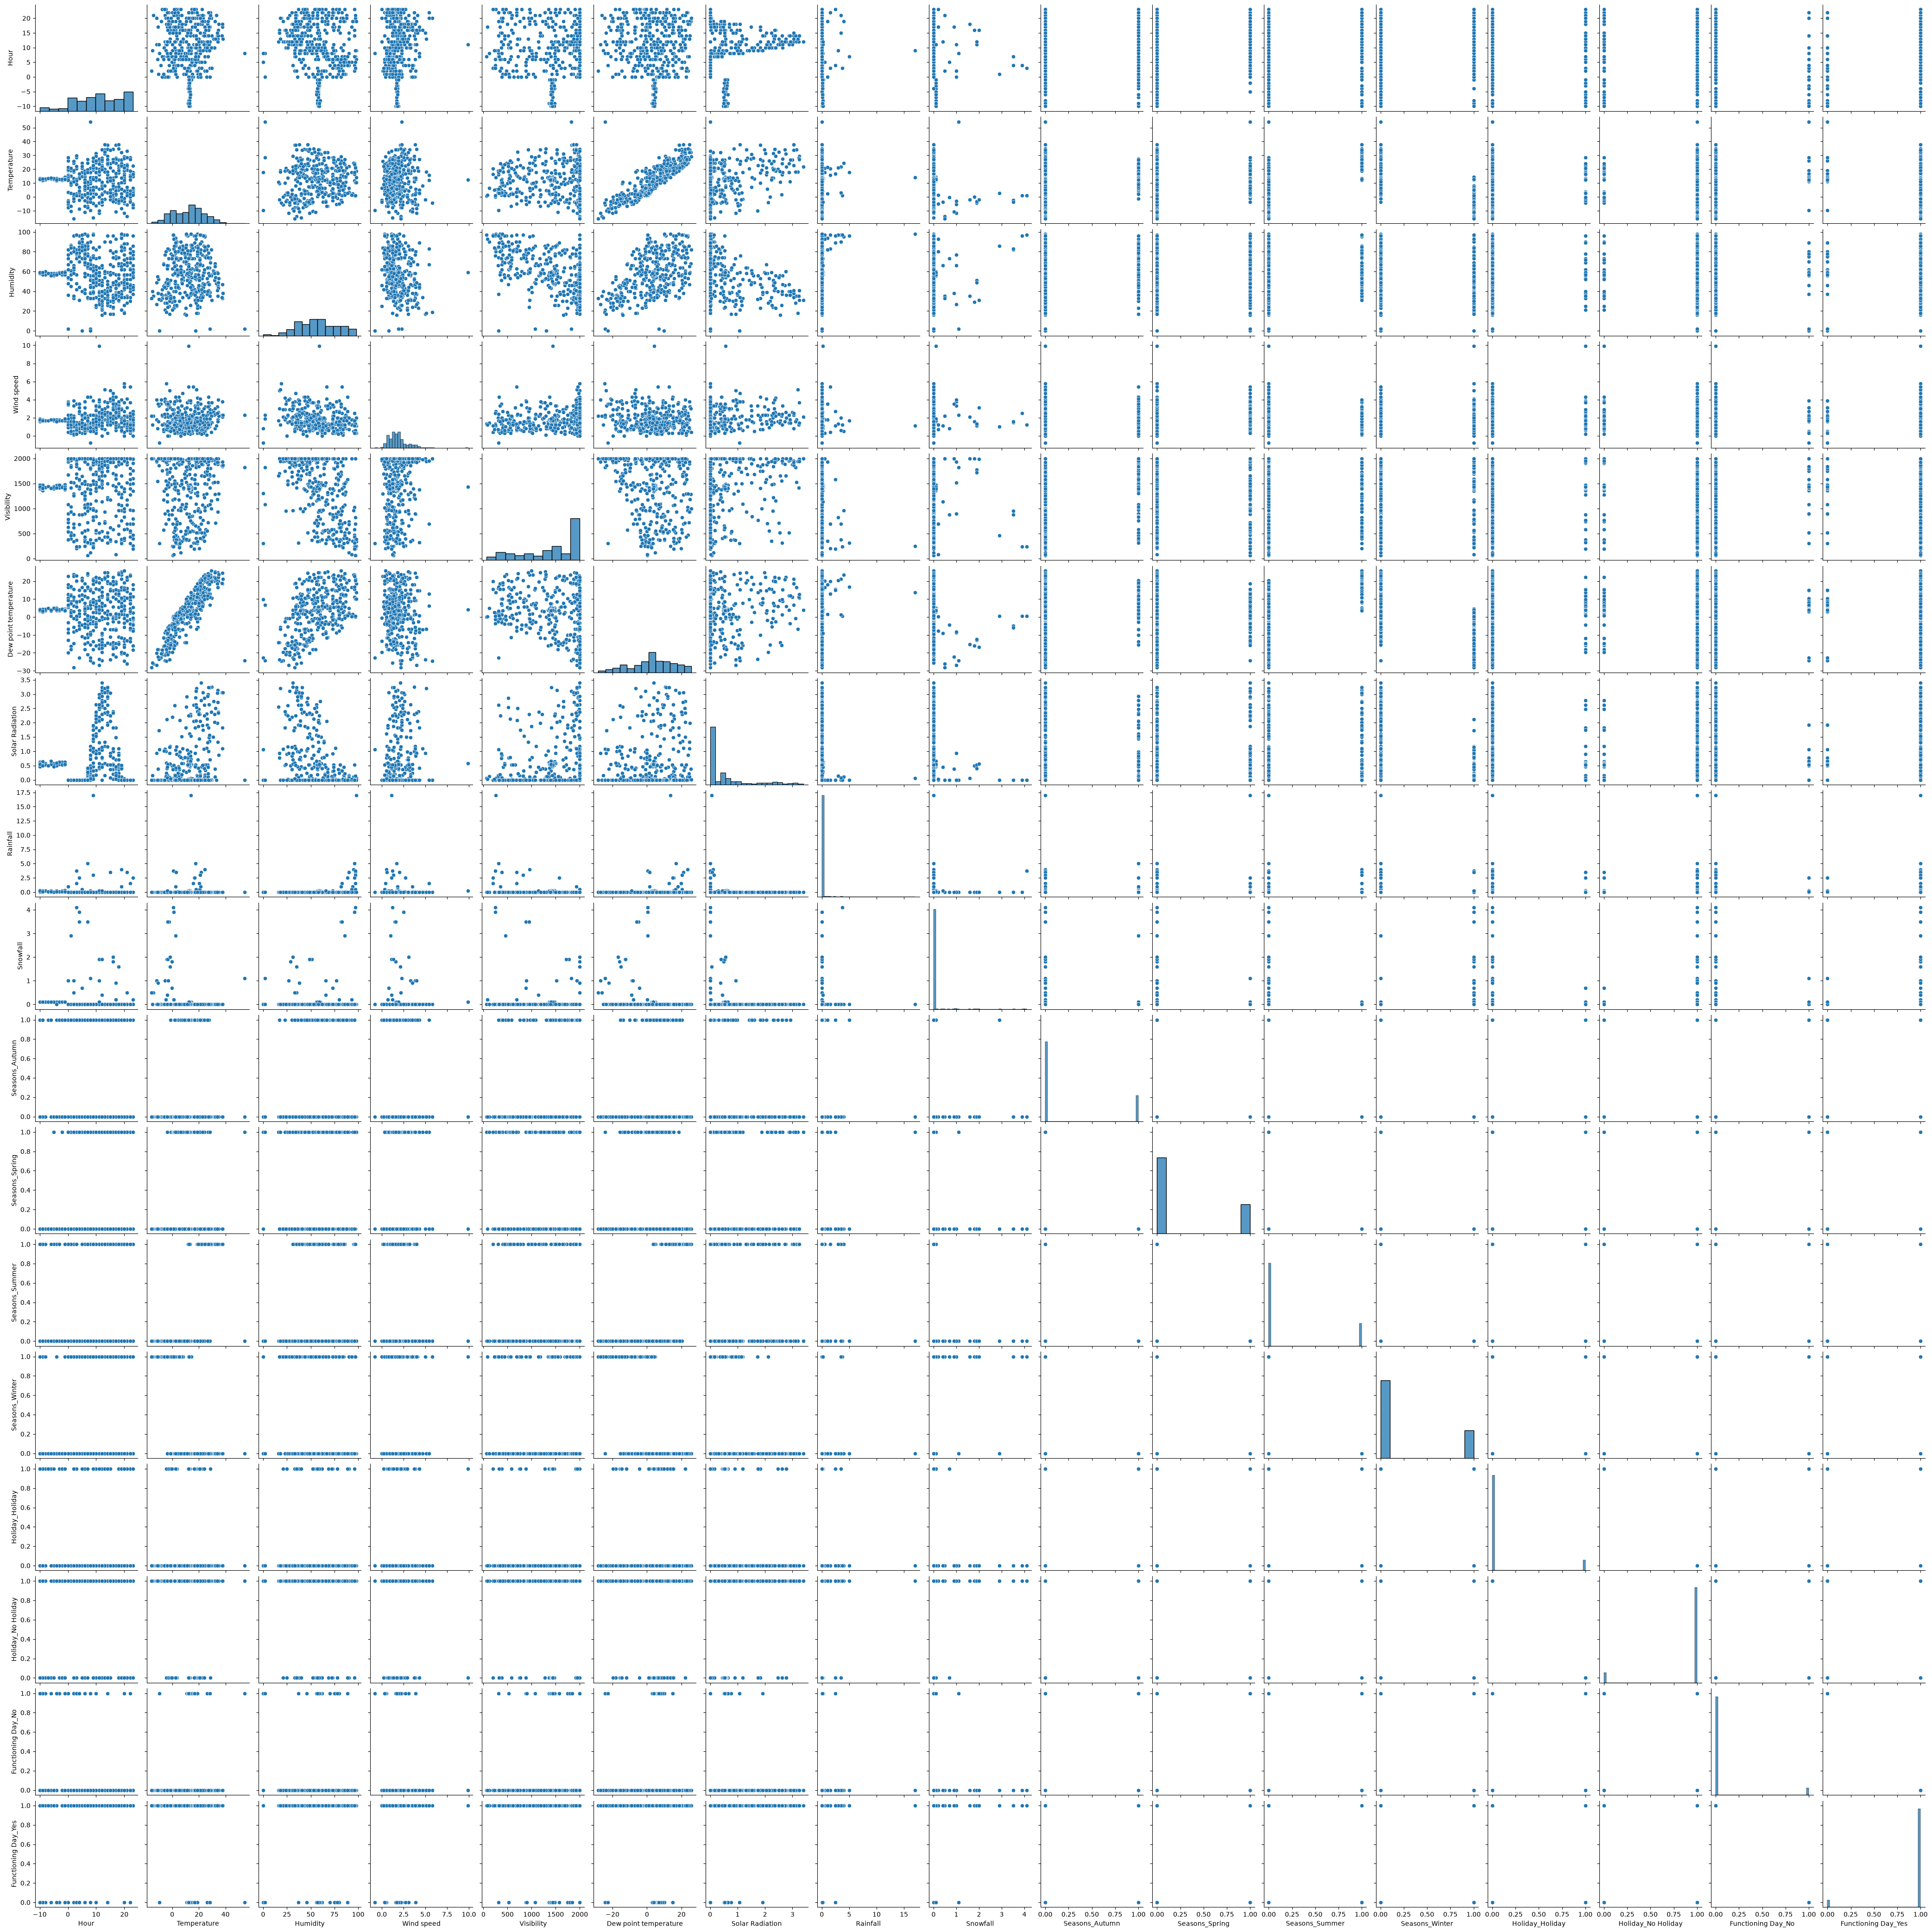

In [12]:
xsample = X.sample(400)
sns.pairplot(xsample)